In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.integrate import quad

import low_rank_rnn.plotting as plotting
import low_rank_rnn.plotting.model as plotting_model
import low_rank_rnn.plotting.style as plotting_style

from low_rank_rnn.analysis import (
    connectivity_covariance,
    connectivity_vectors,
    fit_loading_gaussian,
    project_rank_one_activity,
    sample_loading_gaussian,
    sample_low_rank_rnns,
)
from low_rank_rnn.constants import STIMULUS_WINDOW
from low_rank_rnn.data import generate_perceptual_decision_making_trials
from low_rank_rnn.model import LowRankRNN
from low_rank_rnn.plotting import (
    plot_accuracy_comparison,
    plot_activity_trajectories,
    plot_activity_trajectories_by_stimulus,
    plot_connectivity_covariance,
    plot_connectivity_pairs,
    plot_first_perceptual_decision_making_trials,
    plot_reduced_system_accuracy,
    plot_reduced_system_trajectories,
    plot_trial_outputs,
    set_plot_style,
)
from low_rank_rnn.training import decision_accuracy, train_model

set_plot_style()


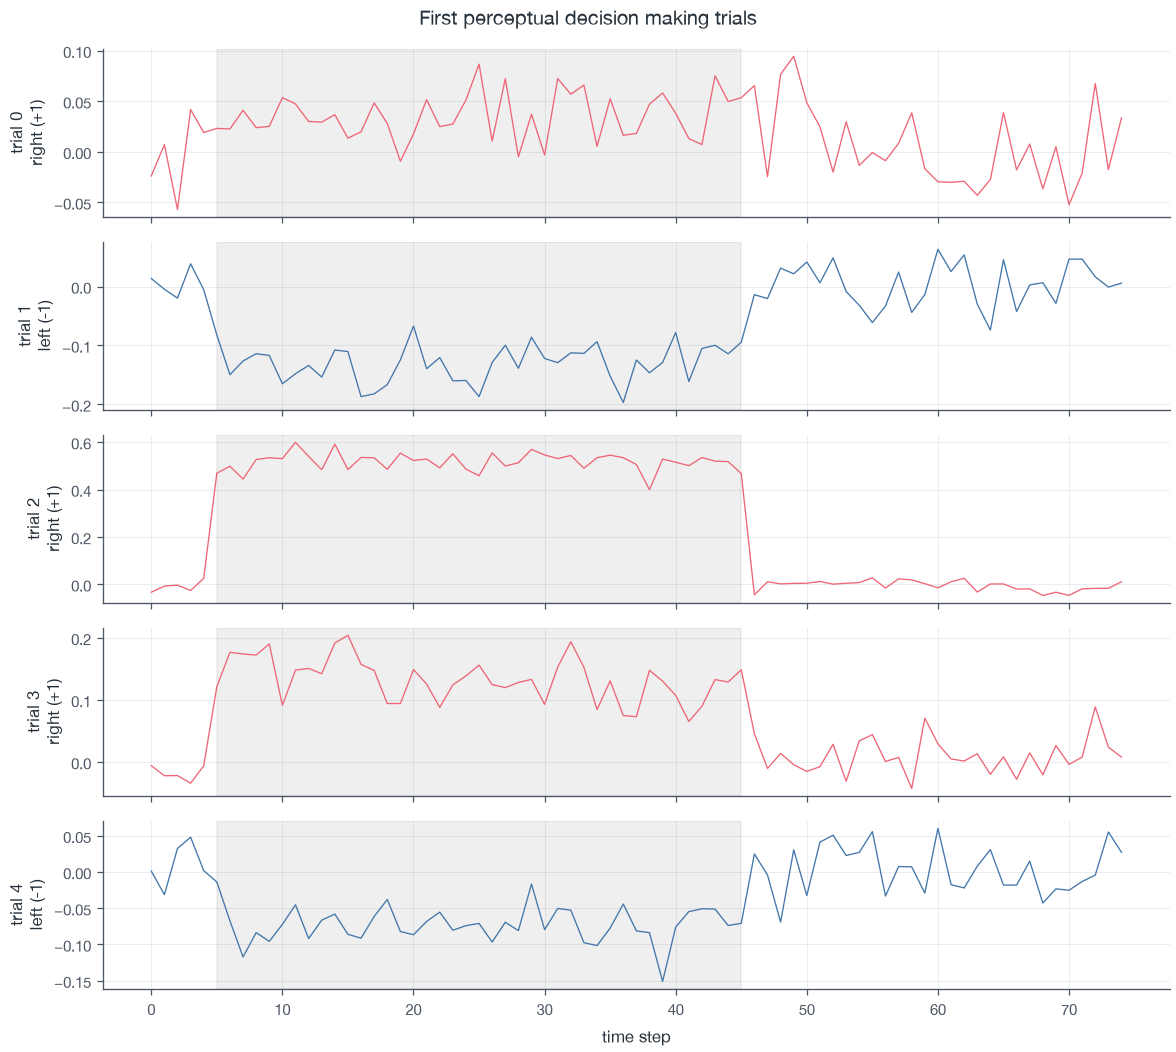

In [2]:
data, labels = generate_perceptual_decision_making_trials(
    num_trials=20,
    rng=np.random.default_rng(2026),
)

fig, axes = plot_first_perceptual_decision_making_trials(
    data,
    labels,
    num_trials=5,
)
plt.show()


In [3]:
torch.manual_seed(2026)
model = LowRankRNN(n_units=128, rank=1)


In [4]:
train_inputs, train_labels = generate_perceptual_decision_making_trials(
    num_trials=200,
    rng=np.random.default_rng(2027),
)
train_inputs = torch.tensor(train_inputs, dtype=torch.float32)
train_labels = torch.tensor(train_labels, dtype=torch.float32)
losses = train_model(model, train_inputs, train_labels)

test_inputs, test_labels = generate_perceptual_decision_making_trials(
    num_trials=160,
    rng=np.random.default_rng(2028),
)
test_inputs = torch.tensor(test_inputs, dtype=torch.float32)
test_labels = torch.tensor(test_labels, dtype=torch.float32)
model.eval()
with torch.no_grad():
    test_outputs, test_states = model(test_inputs)
accuracy = decision_accuracy(model, test_inputs, test_labels)

print(f"Final training loss: {losses[-1]:.4f}")
print(f"Test accuracy on fresh trials: {accuracy:.1%}")


Epoch 100: loss=0.000300
Epoch 200: loss=0.000121
Epoch 300: loss=0.000088
Epoch 400: loss=0.000072
Epoch 500: loss=0.000055
Epoch 600: loss=0.000038
Epoch 700: loss=0.000024
Epoch 800: loss=0.000014
Epoch 900: loss=0.000007
Epoch 1000: loss=0.000003
Final training loss: 0.0000
Test accuracy on fresh trials: 100.0%


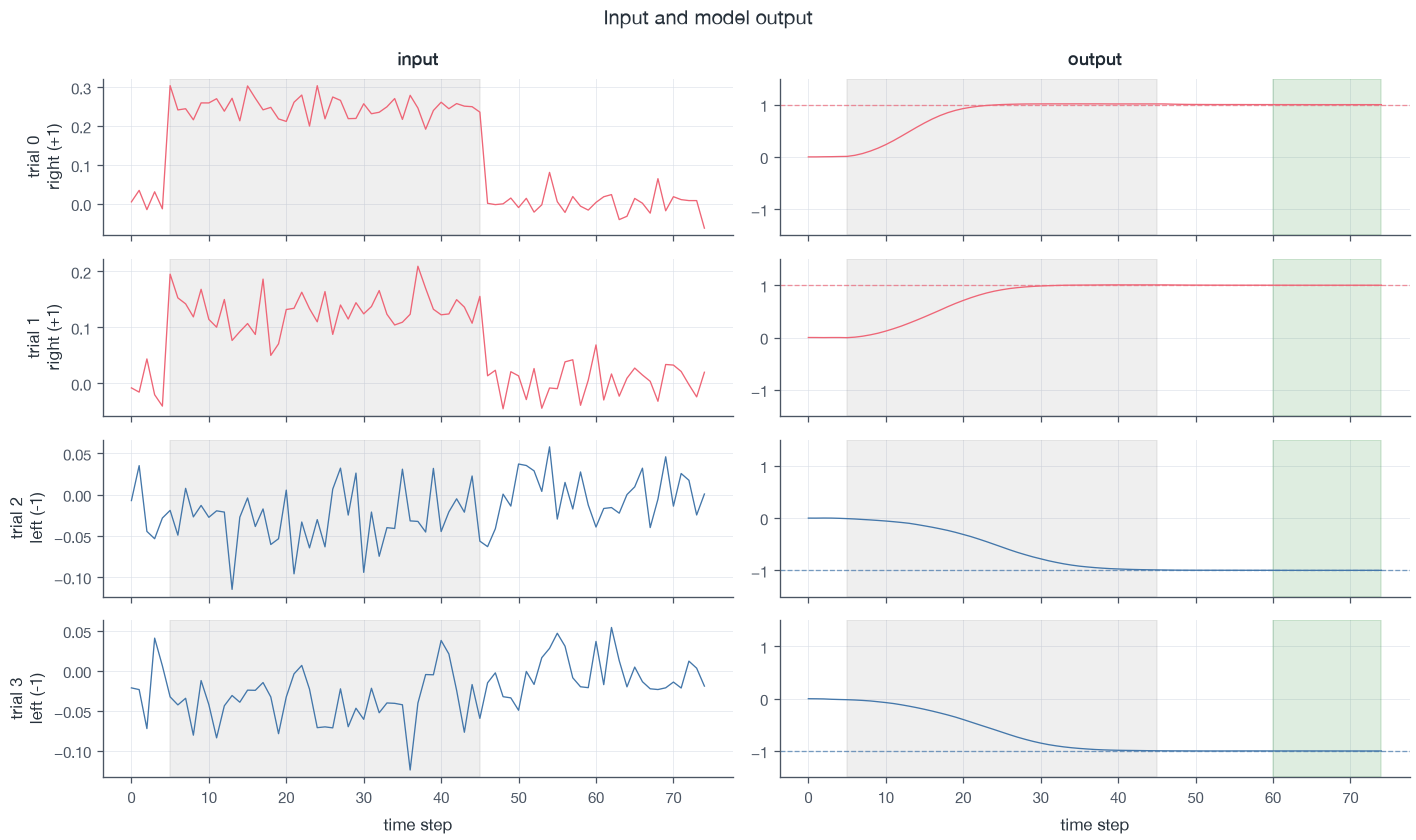

In [5]:
positive_trials = torch.where(test_labels > 0)[0][:2]
negative_trials = torch.where(test_labels < 0)[0][:2]
example_trials = torch.cat((positive_trials, negative_trials))

fig, axes = plot_trial_outputs(
    test_inputs[example_trials].numpy(),
    test_labels[example_trials].numpy(),
    test_outputs[example_trials].numpy(),
)
plt.show()


# Connectivity Space

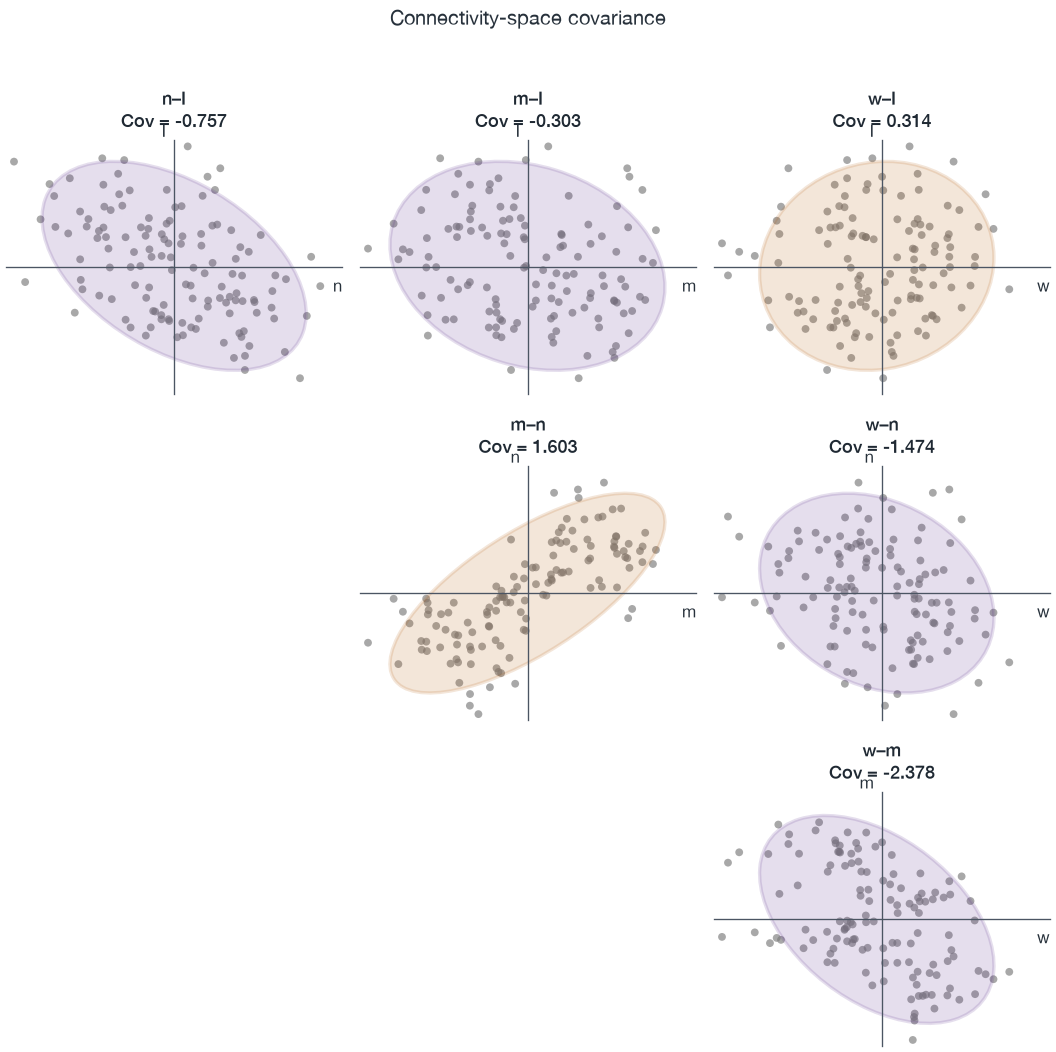

In [6]:
vectors = connectivity_vectors(model)
fig, axes = plot_connectivity_pairs(
    vectors,
    row_names=("I", "n", "m"),
    column_names=("n", "m", "w"),
)
plt.show()


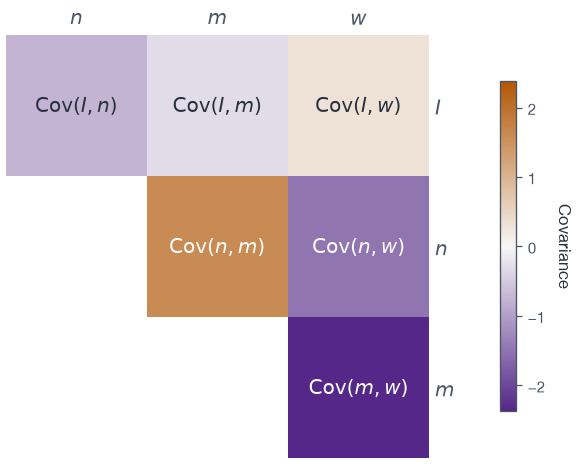

In [7]:
names, covariance = connectivity_covariance(vectors)
fig, ax = plot_connectivity_covariance(names, covariance)
plt.show()


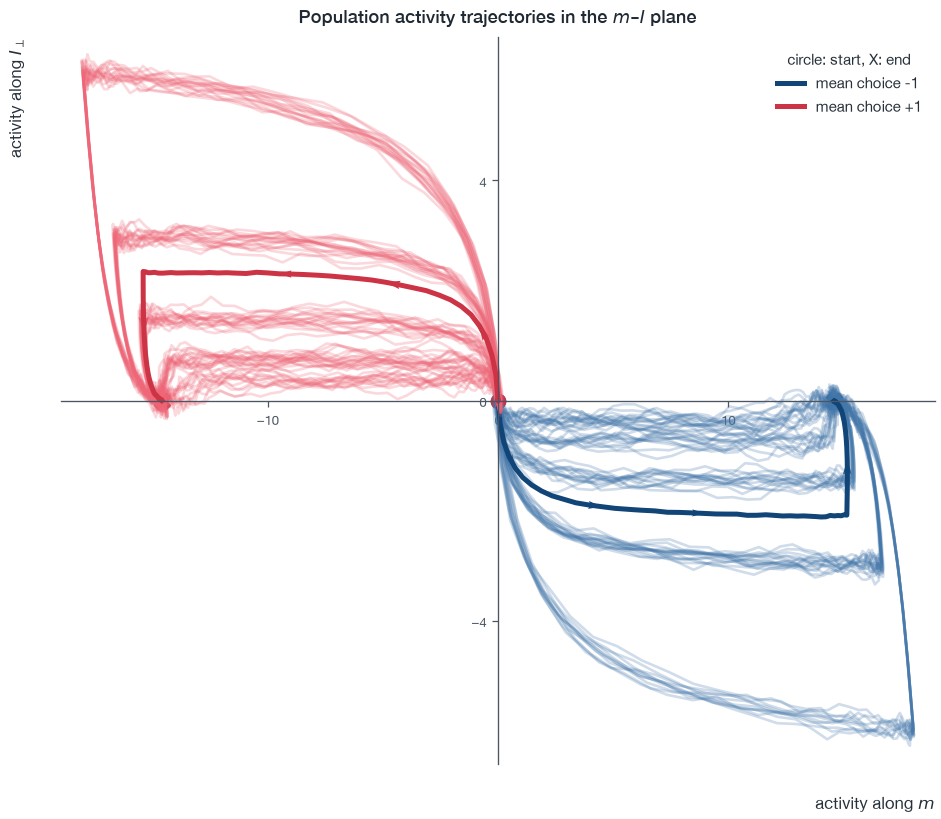

In [8]:
projected_test_states = project_rank_one_activity(test_states, model)
fig, ax = plot_activity_trajectories(projected_test_states, test_labels.numpy())
plt.show()


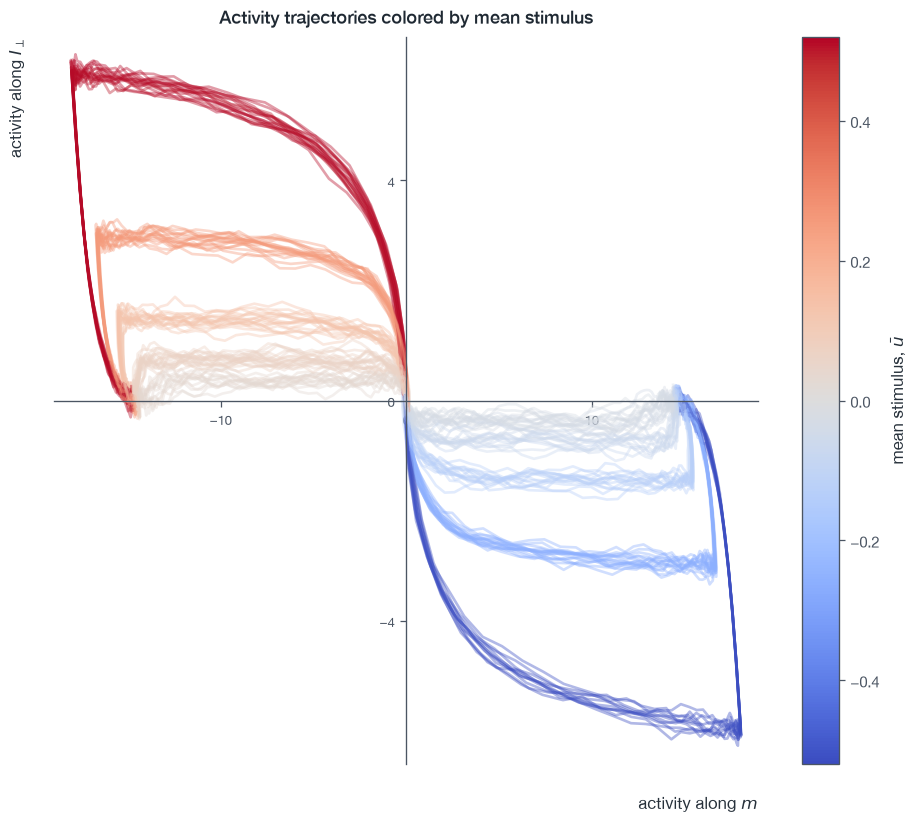

In [ ]:
stimulus_start, stimulus_end = STIMULUS_WINDOW
mean_test_stimuli = (
    test_inputs[:, stimulus_start : stimulus_end + 1].mean(dim=1).numpy()
)
fig, ax = plot_activity_trajectories_by_stimulus(
    projected_test_states,
    mean_test_stimuli,
)
plt.show()


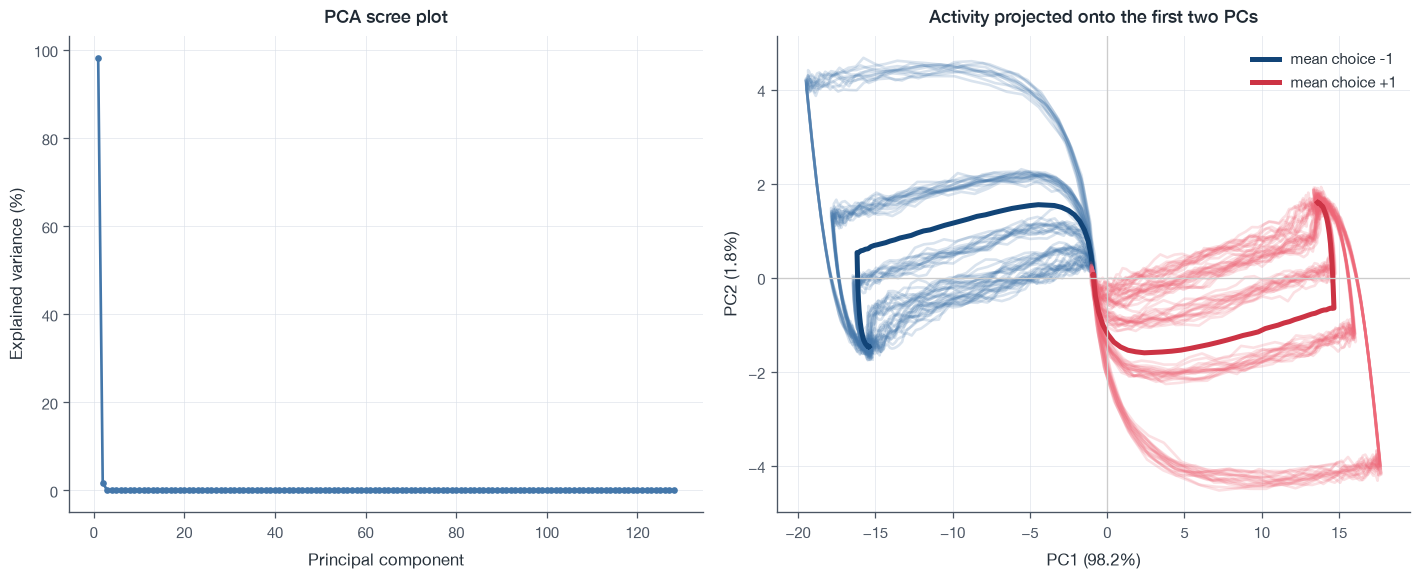

In [ ]:
activity = test_states.detach().cpu().numpy()
n_trials, n_steps, n_units = activity.shape
activity_samples = activity.reshape(-1, n_units)
centered_activity = activity_samples - activity_samples.mean(axis=0, keepdims=True)

_, singular_values, principal_axes = np.linalg.svd(
    centered_activity,
    full_matrices=False,
)
explained_variance_ratio = singular_values**2 / np.sum(singular_values**2)
pc_trajectories = (
    centered_activity @ principal_axes[:2].T
).reshape(n_trials, n_steps, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
component_numbers = np.arange(1, len(explained_variance_ratio) + 1)
axes[0].plot(
    component_numbers,
    100 * explained_variance_ratio,
    marker="o",
    markersize=3,
)
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_title("PCA scree plot")

labels = test_labels.numpy()
for choice, color in plotting.CHOICE_COLORS.items():
    choice_trajectories = pc_trajectories[labels == choice]
    for trajectory in choice_trajectories:
        axes[1].plot(trajectory[:, 0], trajectory[:, 1], color=color, alpha=0.2)

    mean_trajectory = choice_trajectories.mean(axis=0)
    axes[1].plot(
        mean_trajectory[:, 0],
        mean_trajectory[:, 1],
        color=plotting.MEAN_CHOICE_COLORS[choice],
        linewidth=3,
        label=f"mean choice {choice:+d}",
    )

axes[1].axhline(0, color="0.8", linewidth=0.8)
axes[1].axvline(0, color="0.8", linewidth=0.8)
axes[1].set_xlabel(f"PC1 ({explained_variance_ratio[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({explained_variance_ratio[1]:.1%})")
axes[1].set_title("Activity projected onto the first two PCs")
axes[1].legend()
fig.tight_layout()
plt.show()


## Fit a 4D Gaussian to the loading space

Treat each neuron's $(I, n, m, w)$ coordinates in the trained network as one 4D sample, then estimate the joint Gaussian mean and covariance.

In [ ]:
loading_names = tuple(vectors)
gaussian_mean, gaussian_covariance = fit_loading_gaussian(vectors)

print("Loading order:", loading_names)
print("Mean:", np.round(gaussian_mean, 3))
print("Covariance:\n", np.round(gaussian_covariance, 3))


Loading order: ('I', 'n', 'm', 'w')
Mean: [ 0.03   0.003 -0.011 -0.338]
Covariance:
 [[ 1.093 -0.751 -0.301  0.311]
 [-0.751  2.484  1.59  -1.463]
 [-0.301  1.59   2.01  -2.359]
 [ 0.311 -1.463 -2.359 14.24 ]]


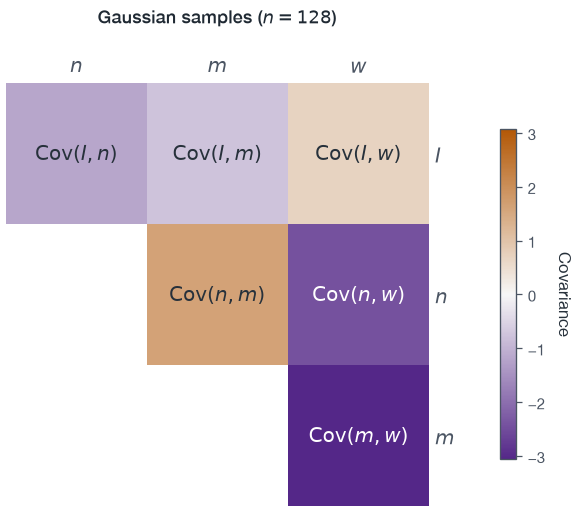

In [12]:
# Match the empirical sample size for a like-for-like covariance comparison.
n_loading_samples = len(vectors[loading_names[0]])
gaussian_rng = np.random.default_rng(2026)
sampled_loadings = sample_loading_gaussian(
    gaussian_mean,
    gaussian_covariance,
    num_samples=n_loading_samples,
    rng=gaussian_rng,
)
sampled_vectors = {
    name: sampled_loadings[:, index]
    for index, name in enumerate(loading_names)
}
sampled_names, sampled_covariance = connectivity_covariance(sampled_vectors)

fig, ax = plot_connectivity_covariance(sampled_names, sampled_covariance)
ax.set_title(f"Gaussian samples ($n={n_loading_samples}$)", pad=18)
plt.show()


## Test networks sampled from the loading Gaussian

Create ten untrained networks from independent loading samples, then compare their decision accuracy with the trained network on the exact same held-out trials.

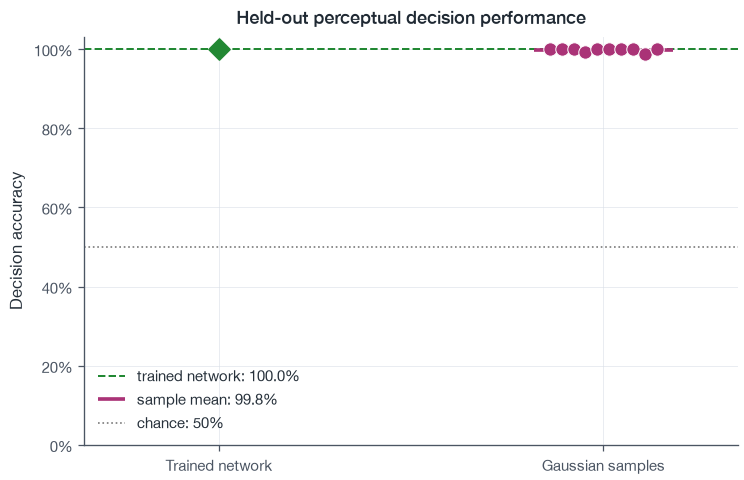

In [ ]:
NUM_SAMPLED_NETWORKS = 10
NUM_NEURONS = model.n_units

sampled_networks = sample_low_rank_rnns(
    loading_names,
    gaussian_mean,
    gaussian_covariance,
    num_networks=NUM_SAMPLED_NETWORKS,
    num_neurons=NUM_NEURONS,
    rng=np.random.default_rng(2026),
)
trained_accuracy = decision_accuracy(model, test_inputs, test_labels)
sampled_accuracies = np.array([
    decision_accuracy(network, test_inputs, test_labels)
    for network in sampled_networks
])

fig, ax = plot_accuracy_comparison(trained_accuracy, sampled_accuracies)
plt.show()


# One Dimensional Dynamical System from Equivalent Circuit

In [14]:
def covariance(cov, v1='n', v2='m', order=['I', 'n', 'm', 'w']):
    index1 = order.index(v1)
    index2 = order.index(v2)
    return cov[index1, index2]

sigma_mn = covariance(gaussian_covariance, 'n', 'm')
sigma_nI = covariance(gaussian_covariance, 'n', 'I')
sigma_mw = covariance(gaussian_covariance, 'm', 'w')


def run_1d_system(inputs, sigma_mn, sigma_nI, gain_fn, k0=0.0, v0=0.0):
    inputs = np.asarray(inputs)
    step_size = model.step_size
    kappa, v = k0, v0
    kappas = np.empty(len(inputs))
    filtered_inputs = np.empty(len(inputs))

    for t, u in enumerate(inputs):
        kappas[t] = kappa
        filtered_inputs[t] = v

        gain = gain_fn(kappa, v)
        kappa += step_size * (
            -kappa + gain * (sigma_mn * kappa + sigma_nI * v)
        )
        v += step_size * (-v + u)

    return kappas, filtered_inputs


def population_gain(k, v):
    var_I = covariance(gaussian_covariance, 'I', 'I')
    var_m = covariance(gaussian_covariance, 'm', 'm')
    delta = np.sqrt(var_m * k**2 + var_I * v**2)
    integral, _ = quad(
        lambda z: (1 - np.tanh(delta * z) ** 2) * np.exp(-z**2 / 2),
        -np.inf,
        np.inf,
    )
    return integral / np.sqrt(2 * np.pi)


def reduced_system_accuracy(
    trajectories,
    labels,
    sigma_mw,
    gain_fn,
    decision_steps=15,
):
    trajectories = np.asarray(trajectories)
    labels = np.asarray(labels)
    readouts = np.array([
        [gain_fn(kappa, v) * sigma_mw * kappa for kappa, v in trajectory]
        for trajectory in trajectories
    ])
    decisions = readouts[:, -decision_steps:].mean(axis=1)
    predictions = np.where(decisions >= 0, 1, -1)
    return np.mean(predictions == labels)

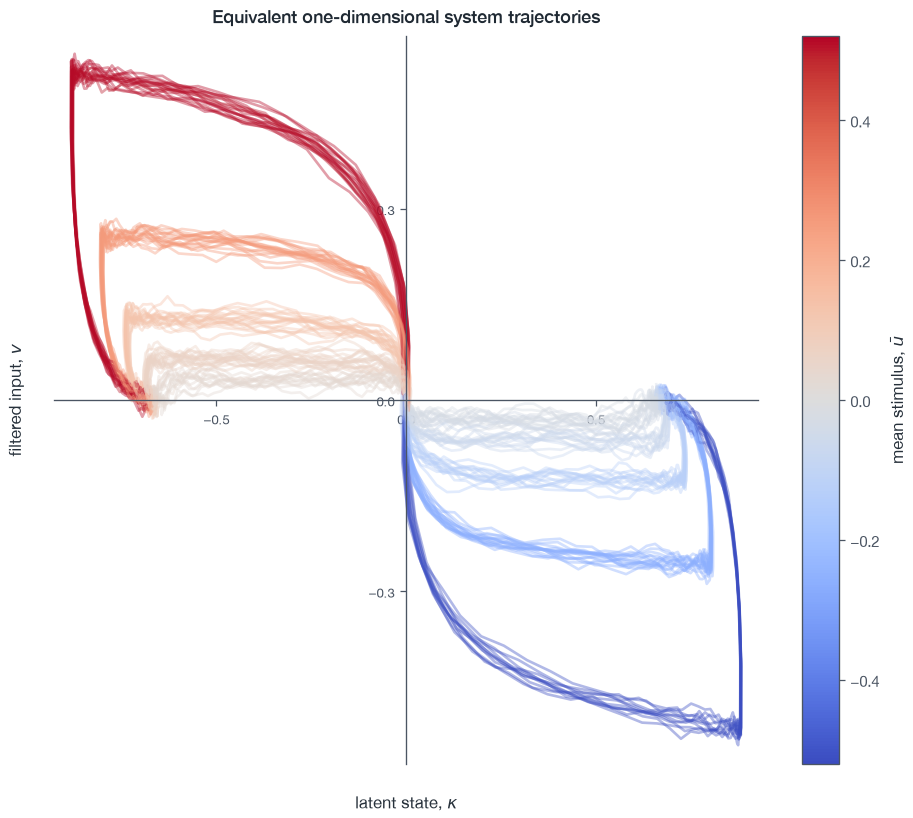

In [15]:
equivalent_trajectories = np.stack([
    np.column_stack(
        run_1d_system(inputs, sigma_mn, sigma_nI, population_gain)
    )
    for inputs in test_inputs.numpy()
])

fig, ax = plot_reduced_system_trajectories(
    equivalent_trajectories,
    mean_test_stimuli,
)
plt.show()

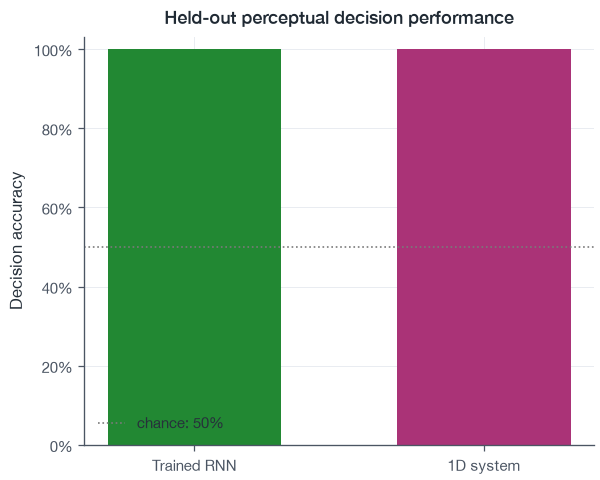

In [16]:
equivalent_accuracy = reduced_system_accuracy(
    equivalent_trajectories,
    test_labels.numpy(),
    sigma_mw,
    population_gain,
)

fig, ax = plot_reduced_system_accuracy(accuracy, equivalent_accuracy)
plt.show()

# Analyzing the Fixed Points